# Geospatial Clustering Analysis

This notebook performs HDBSCAN clustering to identify geographic concentrations of power plants with similar characteristics.

## Objectives
- Apply HDBSCAN clustering to power plant locations
- Identify infrastructure clusters
- Compare clustering for all plants, renewable plants, and fossil plants
- Analyze cluster characteristics

In [1]:
import sys
from pathlib import Path
# Add parent directory to path
parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))
sys.path.append(str(Path.cwd().parent / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import Preprocessor
from src.feature_engineering import FeatureEngineer
from src.clustering import ClusterAnalyzer

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

%matplotlib inline

## 1. Load and Prepare Data

In [2]:
preprocessor = Preprocessor()
data_path = Path.cwd().parent / 'data' / 'raw' / 'global_power_plant_database.csv'

df = preprocessor.load_data(data_path)
df = preprocessor.clean_data(df)
df = preprocessor.filter_valid_generation(df)

engineer = FeatureEngineer()
df = engineer.engineer_all_features(df)

print(f"Prepared dataset: {len(df):,} plants")

2026-03-10 11:10:41,182 - INFO - Loading data from e:\Geospatial Machine Learning for Global Power Plant Efficiency and Infrastructure Inequality\data\raw\global_power_plant_database.csv
2026-03-10 11:10:41,436 - INFO - Dataset loaded: 34936 rows, 36 columns
2026-03-10 11:10:41,437 - INFO - Starting data cleaning. Initial rows: 34936
2026-03-10 11:10:41,436 - INFO - Dataset loaded: 34936 rows, 36 columns
2026-03-10 11:10:41,437 - INFO - Starting data cleaning. Initial rows: 34936
2026-03-10 11:10:41,485 - INFO - Duplicates removed: 0 rows
2026-03-10 11:10:41,488 - INFO - Rows after removing missing critical columns: 34936
2026-03-10 11:10:41,491 - INFO - Data cleaning completed. Final rows: 34936
2026-03-10 11:10:41,492 - INFO - Total rows removed: 0
2026-03-10 11:10:41,493 - INFO - Filtering valid generation data. Initial rows: 34936
2026-03-10 11:10:41,485 - INFO - Duplicates removed: 0 rows
2026-03-10 11:10:41,488 - INFO - Rows after removing missing critical columns: 34936
2026-03-

Prepared dataset: 33,045 plants


## 2. Clustering All Power Plants

In [3]:
cluster_analyzer = ClusterAnalyzer()

df_all, silhouette_all = cluster_analyzer.perform_clustering(
    df.copy(), 
    min_cluster_size=50, 
    min_samples=10
)

print(f"\nSilhouette Score (All Plants): {silhouette_all:.3f}" if silhouette_all else "Silhouette score not available")

2026-03-10 11:10:41,894 - INFO - Starting HDBSCAN clustering with min_cluster_size=50, min_samples=10
2026-03-10 11:10:42,839 - INFO - Clustering completed: 84 clusters found, 18894 noise points
2026-03-10 11:10:42,839 - INFO - Clustering completed: 84 clusters found, 18894 noise points
2026-03-10 11:10:45,255 - INFO - Silhouette score (excluding noise): 0.389
2026-03-10 11:10:45,255 - INFO - Silhouette score (excluding noise): 0.389



Silhouette Score (All Plants): 0.389


In [4]:
summary_all = cluster_analyzer.get_cluster_summary(df_all)
print("\nCluster Summary (All Plants):")
print(summary_all.head(15))

2026-03-10 11:10:45,267 - INFO - Generating cluster summary
2026-03-10 11:10:45,323 - INFO - Cluster summary generated for 84 clusters
2026-03-10 11:10:45,323 - INFO - Cluster summary generated for 84 clusters



Cluster Summary (All Plants):
    cluster  plant_count dominant_fuel  mean_capacity_mw  centroid_lat  \
0         1         2512         Hydro            55.035       -20.575   
1        63         1179         Solar             2.500        41.746   
2        56          455         Solar             4.721        35.526   
3        83          452         Solar             4.832        51.975   
4        55          389          Wind            49.034        42.668   
5         4          360           Gas           114.252       -32.782   
6        78          345         Solar             1.874        52.065   
7        69          305         Solar             1.598        43.959   
8        57          218         Solar             1.771        35.074   
9        15          212         Hydro           108.682        61.133   
10        9          208           Gas           873.096        40.483   
11       17          200          Wind           156.856        34.524   
12     

In [5]:
n_clusters = len(summary_all)
n_noise = (df_all['cluster'] == -1).sum()
print(f"\nTotal clusters identified: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(df_all)*100:.1f}%)")
print(f"Clustered points: {len(df_all) - n_noise} ({(len(df_all)-n_noise)/len(df_all)*100:.1f}%)")


Total clusters identified: 84
Noise points: 18894 (57.2%)
Clustered points: 14151 (42.8%)


## 3. Visualize All Plants Clustering

2026-03-10 11:10:45,364 - INFO - Creating cluster map: HDBSCAN Clustering: All Power Plants
2026-03-10 11:10:45,998 - INFO - Cluster map saved to e:\Geospatial Machine Learning for Global Power Plant Efficiency and Infrastructure Inequality\figures\cluster_map_all_notebook.png
2026-03-10 11:10:45,998 - INFO - Cluster map saved to e:\Geospatial Machine Learning for Global Power Plant Efficiency and Infrastructure Inequality\figures\cluster_map_all_notebook.png


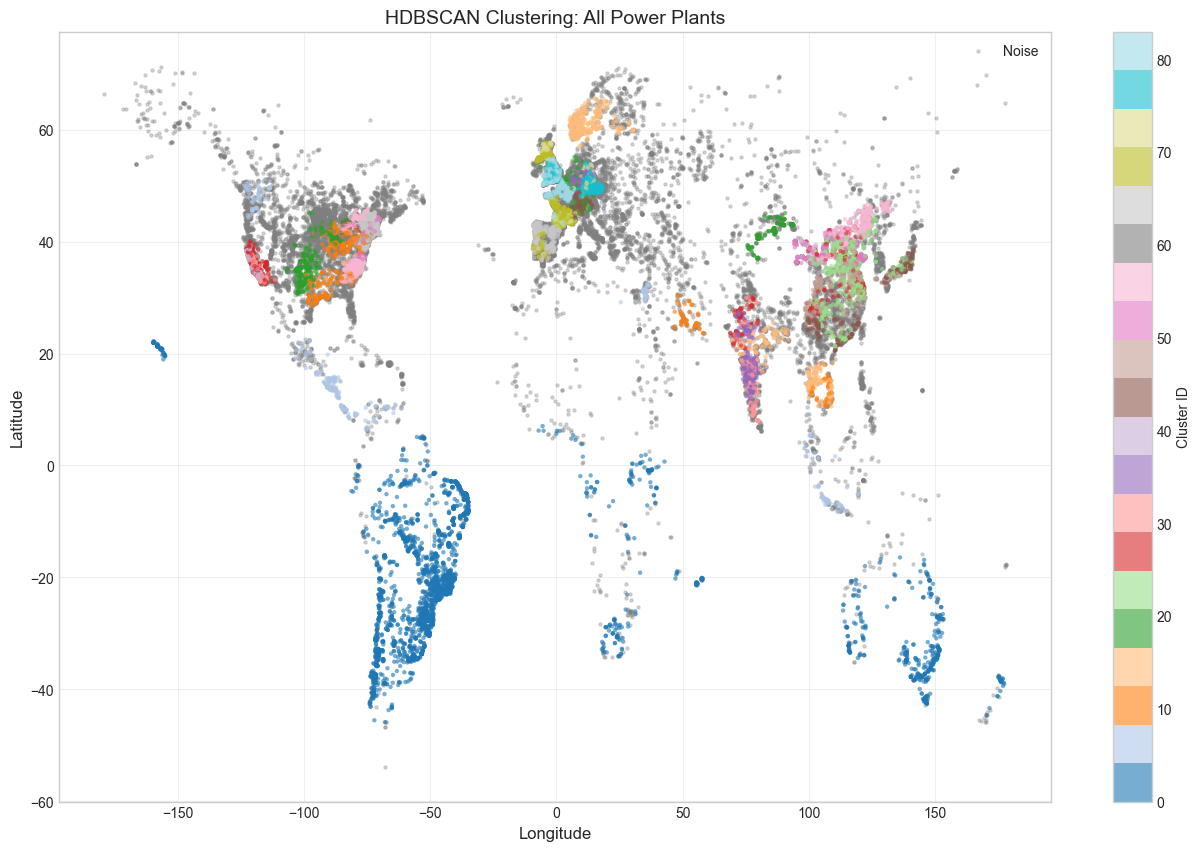

In [6]:
figures_dir = Path.cwd().parent / 'figures'
cluster_analyzer.plot_cluster_map(
    df_all, 
    'HDBSCAN Clustering: All Power Plants', 
    figures_dir / 'cluster_map_all_notebook.png'
)

## 4. Cluster Size Distribution

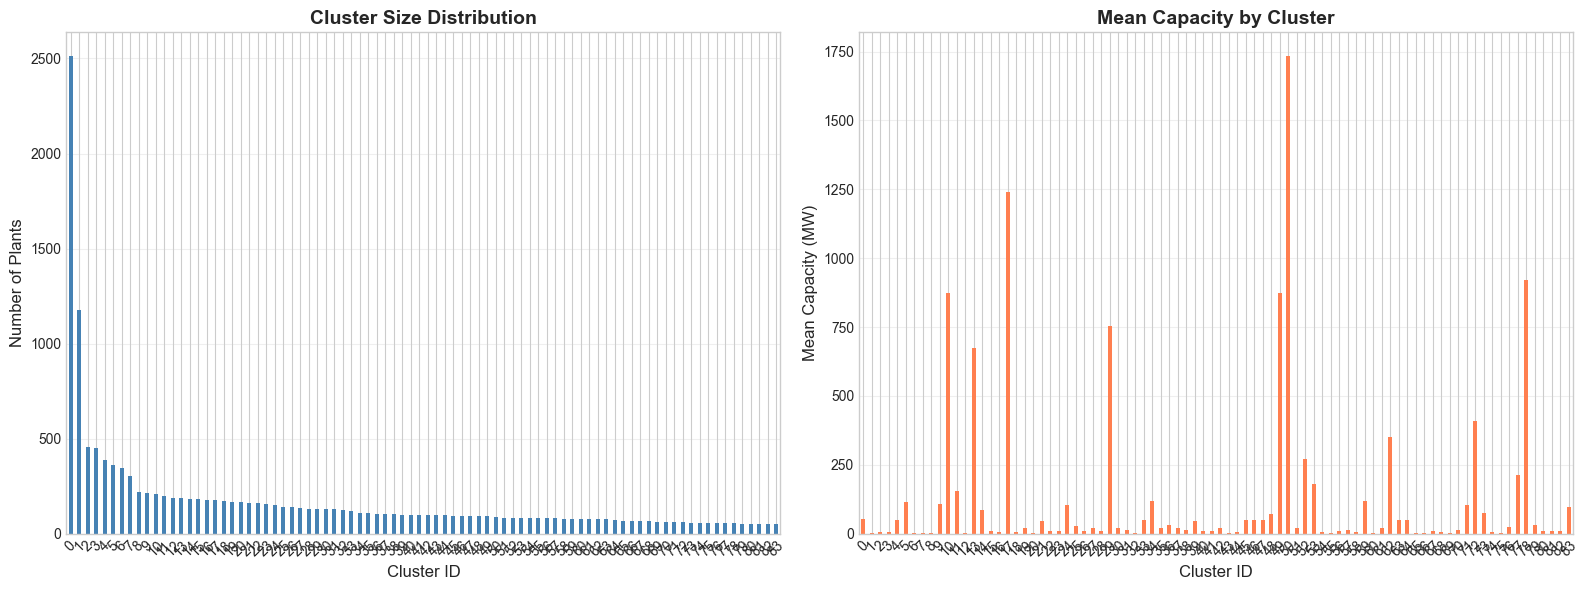

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

summary_all['plant_count'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Cluster ID', fontsize=12)
axes[0].set_ylabel('Number of Plants', fontsize=12)
axes[0].set_title('Cluster Size Distribution', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

summary_all['mean_capacity_mw'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_xlabel('Cluster ID', fontsize=12)
axes[1].set_ylabel('Mean Capacity (MW)', fontsize=12)
axes[1].set_title('Mean Capacity by Cluster', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(figures_dir / 'cluster_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Clustering Renewable Plants

In [8]:
df_renewable = df[df['is_renewable'] == 1].copy()
print(f"Renewable plants: {len(df_renewable):,}")

cluster_analyzer_renewable = ClusterAnalyzer()
df_renewable, silhouette_renewable = cluster_analyzer_renewable.perform_clustering(
    df_renewable, 
    min_cluster_size=50, 
    min_samples=10
)

print(f"Silhouette Score (Renewable): {silhouette_renewable:.3f}" if silhouette_renewable else "Silhouette score not available")

2026-03-10 11:10:48,362 - INFO - Starting HDBSCAN clustering with min_cluster_size=50, min_samples=10


Renewable plants: 24,312


2026-03-10 11:10:49,197 - INFO - Clustering completed: 45 clusters found, 8570 noise points
2026-03-10 11:10:53,145 - INFO - Silhouette score (excluding noise): 0.283
2026-03-10 11:10:53,145 - INFO - Silhouette score (excluding noise): 0.283


Silhouette Score (Renewable): 0.283


In [9]:
summary_renewable = cluster_analyzer_renewable.get_cluster_summary(df_renewable)
print("\nCluster Summary (Renewable Plants):")
print(summary_renewable.head(10))

2026-03-10 11:10:53,163 - INFO - Generating cluster summary
2026-03-10 11:10:53,216 - INFO - Cluster summary generated for 45 clusters
2026-03-10 11:10:53,216 - INFO - Cluster summary generated for 45 clusters



Cluster Summary (Renewable Plants):
   cluster  plant_count dominant_fuel  mean_capacity_mw  centroid_lat  \
0        8         7616         Solar            15.328        48.340   
1        3         1467         Hydro            61.603       -20.633   
2       42         1209         Solar             2.497        42.026   
3       39          436         Solar             4.758        35.533   
4       34          386          Wind            49.029        42.705   
5       30          284         Solar             1.362        35.426   
6       16          240          Wind           168.298        36.368   
7       18          233         Solar            24.403        20.233   
8        0          230         Hydro            79.905       -34.975   
9       41          174         Solar             1.739        35.050   

   centroid_lon  cluster_id  
0         2.973           8  
1       -51.557           3  
2       -73.714          42  
3       -78.856          39  
4       1

2026-03-10 11:10:53,236 - INFO - Creating cluster map: HDBSCAN Clustering: Renewable Power Plants
2026-03-10 11:10:54,058 - INFO - Cluster map saved to e:\Geospatial Machine Learning for Global Power Plant Efficiency and Infrastructure Inequality\figures\cluster_map_renewable_notebook.png
2026-03-10 11:10:54,058 - INFO - Cluster map saved to e:\Geospatial Machine Learning for Global Power Plant Efficiency and Infrastructure Inequality\figures\cluster_map_renewable_notebook.png


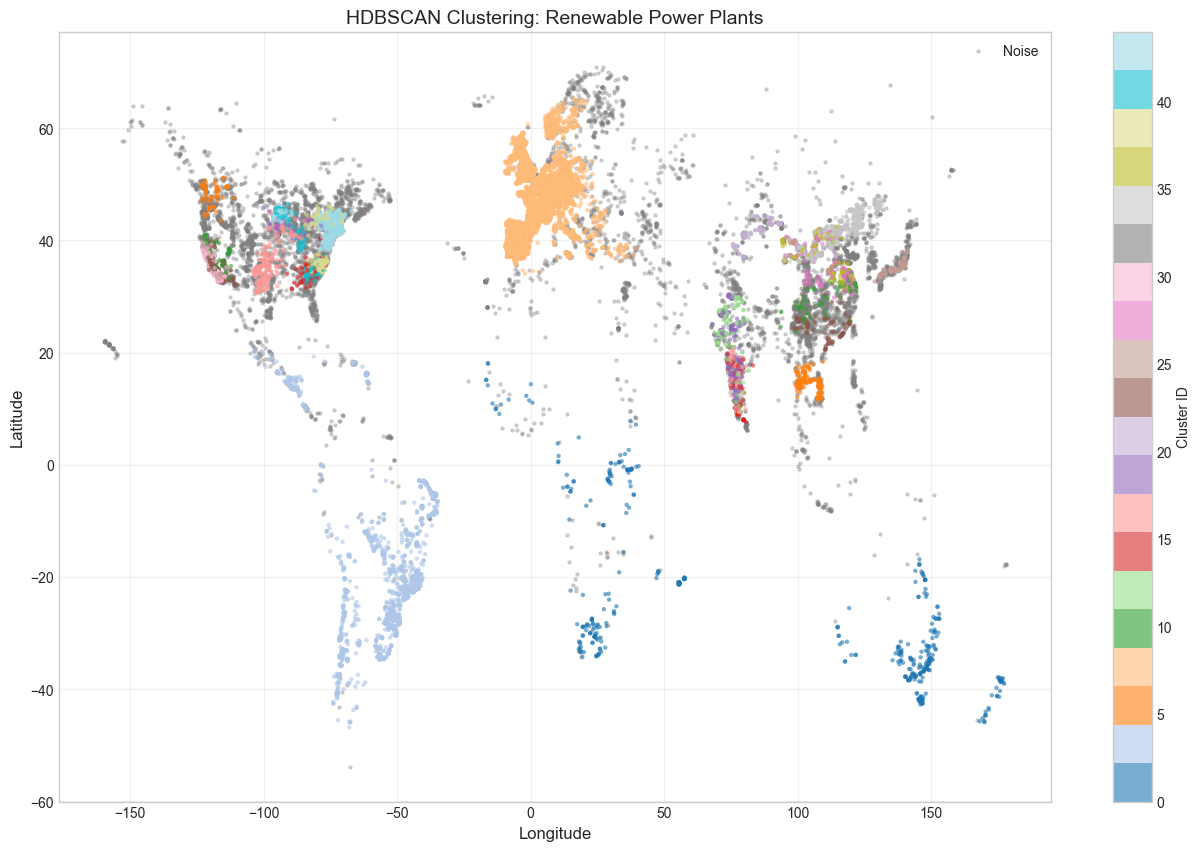

In [10]:
cluster_analyzer_renewable.plot_cluster_map(
    df_renewable, 
    'HDBSCAN Clustering: Renewable Power Plants', 
    figures_dir / 'cluster_map_renewable_notebook.png'
)

## 6. Clustering Fossil Fuel Plants

In [11]:
df_fossil = df[df['is_renewable'] == 0].copy()
print(f"Fossil fuel plants: {len(df_fossil):,}")

cluster_analyzer_fossil = ClusterAnalyzer()
df_fossil, silhouette_fossil = cluster_analyzer_fossil.perform_clustering(
    df_fossil, 
    min_cluster_size=50, 
    min_samples=10
)

print(f"Silhouette Score (Fossil): {silhouette_fossil:.3f}" if silhouette_fossil else "Silhouette score not available")

2026-03-10 11:10:54,402 - INFO - Starting HDBSCAN clustering with min_cluster_size=50, min_samples=10


Fossil fuel plants: 8,733


2026-03-10 11:10:54,646 - INFO - Clustering completed: 5 clusters found, 647 noise points
2026-03-10 11:10:55,817 - INFO - Silhouette score (excluding noise): 0.303
2026-03-10 11:10:55,817 - INFO - Silhouette score (excluding noise): 0.303


Silhouette Score (Fossil): 0.303


In [12]:
summary_fossil = cluster_analyzer_fossil.get_cluster_summary(df_fossil)
print("\nCluster Summary (Fossil Fuel Plants):")
print(summary_fossil.head(10))

2026-03-10 11:10:55,831 - INFO - Generating cluster summary
2026-03-10 11:10:55,859 - INFO - Cluster summary generated for 5 clusters
2026-03-10 11:10:55,859 - INFO - Cluster summary generated for 5 clusters



Cluster Summary (Fossil Fuel Plants):
   cluster  plant_count dominant_fuel  mean_capacity_mw  centroid_lat  \
0        0         4302          Coal           687.337        32.003   
1        2         3167           Gas           317.358        37.688   
2        4          431           Oil             2.723       -23.180   
3        3          110           Oil             2.377        -7.761   
4        1           76           Oil             5.963        62.452   

   centroid_lon  cluster_id  
0        71.994           0  
1       -91.618           2  
2       -47.593           4  
3       -47.597           3  
4      -154.137           1  


2026-03-10 11:10:55,881 - INFO - Creating cluster map: HDBSCAN Clustering: Fossil Fuel Power Plants
2026-03-10 11:10:56,518 - INFO - Cluster map saved to e:\Geospatial Machine Learning for Global Power Plant Efficiency and Infrastructure Inequality\figures\cluster_map_fossil_notebook.png
2026-03-10 11:10:56,518 - INFO - Cluster map saved to e:\Geospatial Machine Learning for Global Power Plant Efficiency and Infrastructure Inequality\figures\cluster_map_fossil_notebook.png


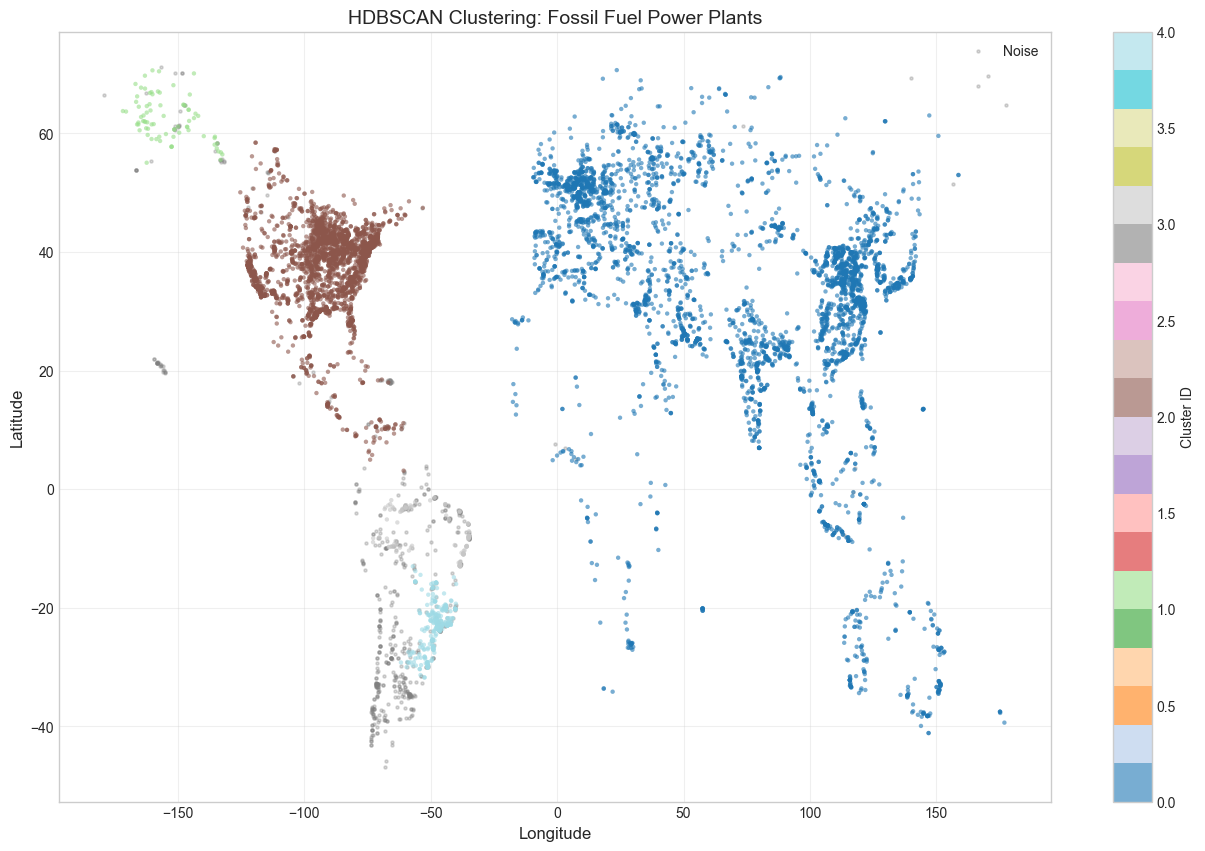

In [13]:
cluster_analyzer_fossil.plot_cluster_map(
    df_fossil, 
    'HDBSCAN Clustering: Fossil Fuel Power Plants', 
    figures_dir / 'cluster_map_fossil_notebook.png'
)

## 7. Comparative Analysis

In [14]:
comparison_df = pd.DataFrame({
    'Category': ['All Plants', 'Renewable', 'Fossil Fuel'],
    'Total Plants': [len(df_all), len(df_renewable), len(df_fossil)],
    'Clusters Found': [
        len(summary_all),
        len(summary_renewable),
        len(summary_fossil)
    ],
    'Noise Points': [
        (df_all['cluster'] == -1).sum(),
        (df_renewable['cluster'] == -1).sum(),
        (df_fossil['cluster'] == -1).sum()
    ],
    'Silhouette Score': [
        silhouette_all if silhouette_all else np.nan,
        silhouette_renewable if silhouette_renewable else np.nan,
        silhouette_fossil if silhouette_fossil else np.nan
    ]
})

comparison_df['Clustering Rate (%)'] = (
    (comparison_df['Total Plants'] - comparison_df['Noise Points']) / 
    comparison_df['Total Plants'] * 100
).round(1)

print("\nClustering Comparison:")
print(comparison_df.to_string(index=False))


Clustering Comparison:
   Category  Total Plants  Clusters Found  Noise Points  Silhouette Score  Clustering Rate (%)
 All Plants         33045              84         18894          0.389478                 42.8
  Renewable         24312              45          8570          0.282962                 64.7
Fossil Fuel          8733               5           647          0.302559                 92.6


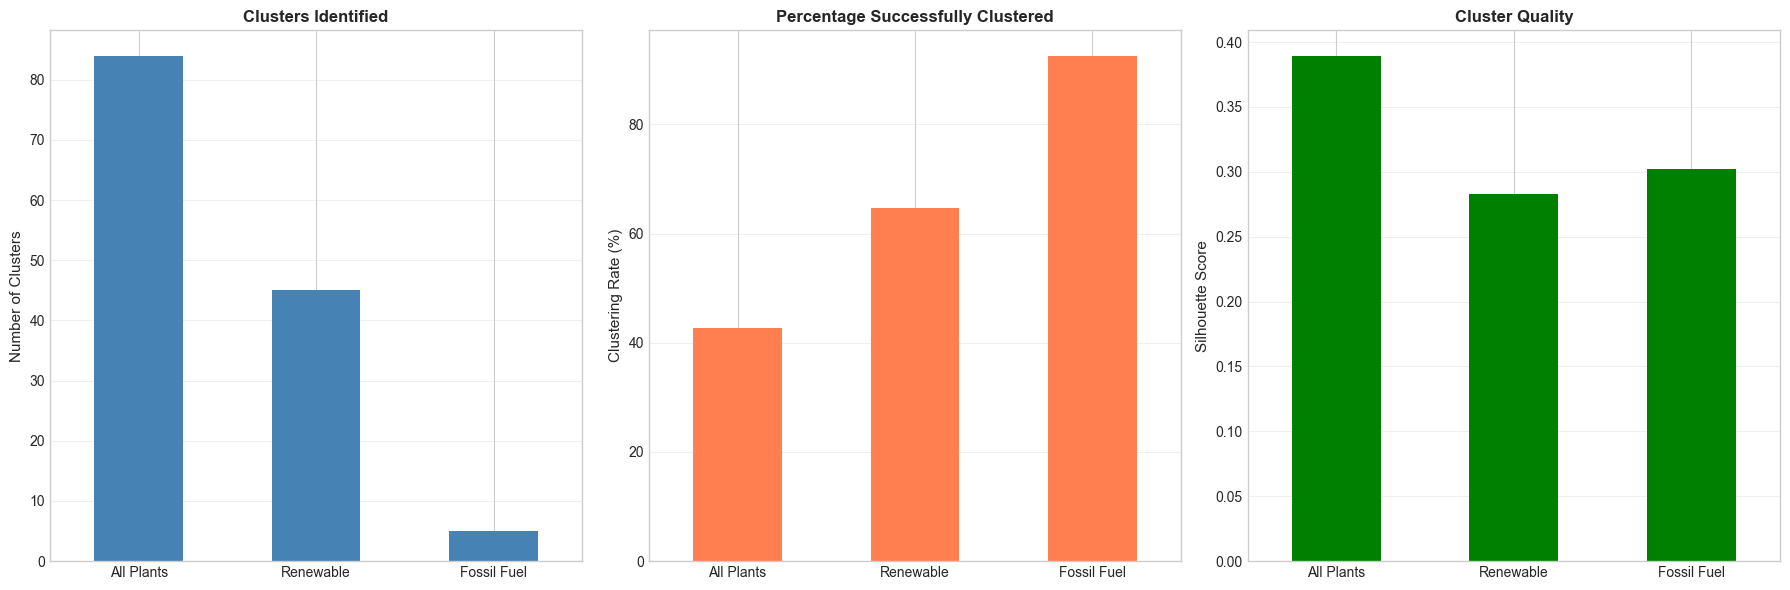

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

comparison_df.plot(x='Category', y='Clusters Found', kind='bar', ax=axes[0], 
                   color='steelblue', legend=False)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Clusters', fontsize=11)
axes[0].set_title('Clusters Identified', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

comparison_df.plot(x='Category', y='Clustering Rate (%)', kind='bar', ax=axes[1], 
                   color='coral', legend=False)
axes[1].set_xlabel('')
axes[1].set_ylabel('Clustering Rate (%)', fontsize=11)
axes[1].set_title('Percentage Successfully Clustered', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

comparison_df.plot(x='Category', y='Silhouette Score', kind='bar', ax=axes[2], 
                   color='green', legend=False)
axes[2].set_xlabel('')
axes[2].set_ylabel('Silhouette Score', fontsize=11)
axes[2].set_title('Cluster Quality', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=0)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(figures_dir / 'clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Geographic Cluster Centroids

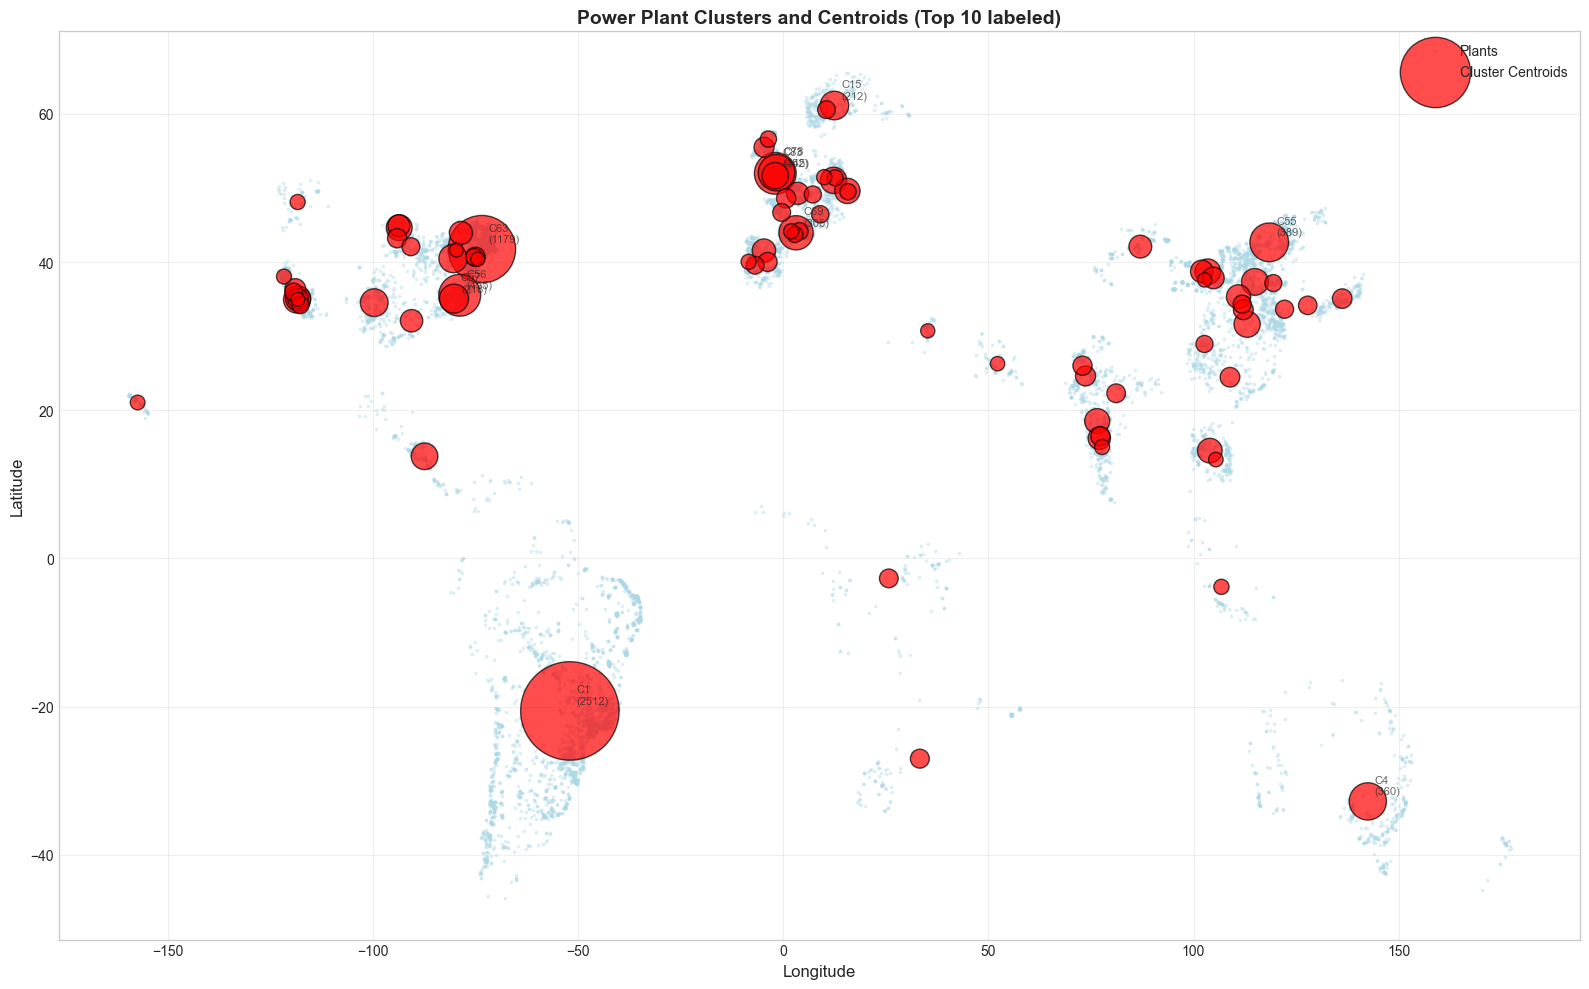

In [16]:
fig, ax = plt.subplots(figsize=(16, 10))

ax.scatter(df_all[df_all['cluster'] != -1]['longitude'], 
          df_all[df_all['cluster'] != -1]['latitude'],
          c='lightblue', s=3, alpha=0.3, label='Plants')

ax.scatter(summary_all['centroid_lon'], summary_all['centroid_lat'],
          c='red', s=summary_all['plant_count']*2, alpha=0.7, 
          edgecolors='black', linewidths=1, label='Cluster Centroids')

for idx, row in summary_all.head(10).iterrows():
    ax.annotate(f"C{row['cluster_id']}\n({row['plant_count']})", 
                xy=(row['centroid_lon'], row['centroid_lat']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.7)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Power Plant Clusters and Centroids (Top 10 labeled)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'cluster_centroids.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Dominant Fuel Types by Cluster

In [17]:
fuel_distribution = summary_all['dominant_fuel'].value_counts()
print("\nDominant fuel types across clusters:")
print(fuel_distribution)


Dominant fuel types across clusters:
dominant_fuel
Solar    47
Wind     13
Hydro    11
Gas       6
Coal      6
Oil       1
Name: count, dtype: int64


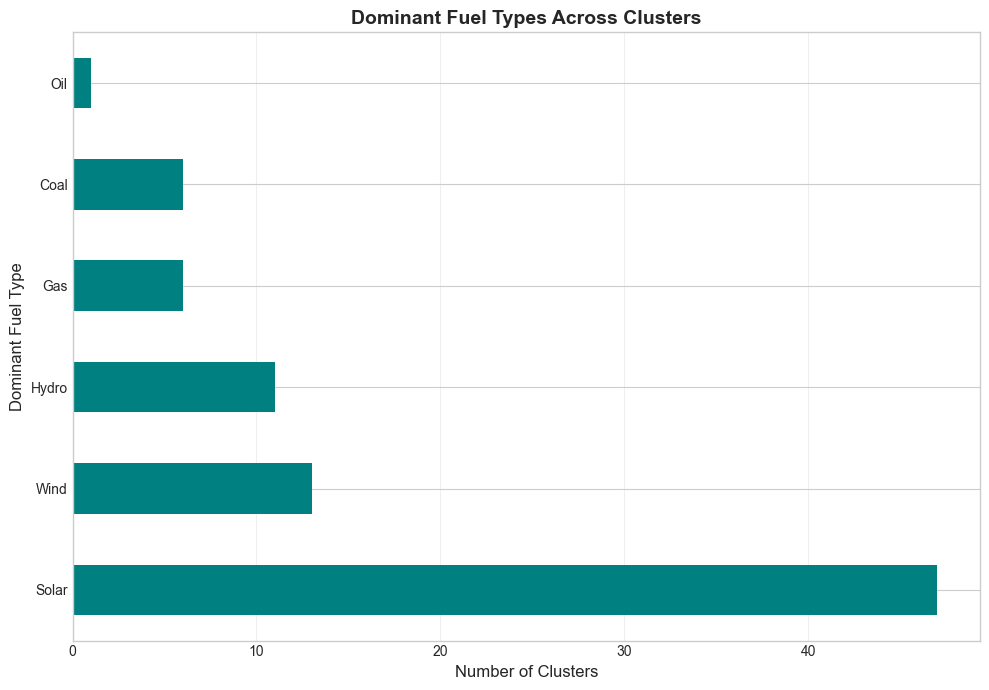

In [18]:
fig, ax = plt.subplots(figsize=(10, 7))

fuel_distribution.plot(kind='barh', ax=ax, color='teal')
ax.set_xlabel('Number of Clusters', fontsize=12)
ax.set_ylabel('Dominant Fuel Type', fontsize=12)
ax.set_title('Dominant Fuel Types Across Clusters', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(figures_dir / 'cluster_fuel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

Key findings from clustering analysis:

1. **Cluster Detection**: HDBSCAN successfully identifies geographic concentrations of power plants
2. **All Plants**: Broad clusters reflect industrial and population centers
3. **Renewable Clusters**: Often concentrated in regions with favorable natural resources
4. **Fossil Clusters**: Tend to be near fuel sources, ports, or urban demand centers
5. **Cluster Quality**: Silhouette scores indicate reasonable separation between clusters
6. **Noise Points**: Isolated plants in rural areas or unique locations
7. **Dominant Fuels**: Cluster composition reflects regional energy strategies

These clusters can inform regional infrastructure planning and policy analysis.